In [1]:
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Generating the dataset

We will generate a synthetic dataset, generated by solving the Lorentz system using the Euler method. The Lorenz equations are defined as:

$$
\dot{x} = \sigma (y-x)
$$
$$
\dot{y} = -y -zx + \rho x
$$
$$
\dot{z} = -\beta z +xy
$$

where $(x, y, z)$ are the variables and $(\sigma , \rho , \beta)$ are parameters. 

In [2]:
npoints = 1000
sigma, rho, beta = 10, 28, 8 / 3
x, y, z = [0], [-0.01], [9]
h = 0.01

for _ in range(npoints - 1):
    x_t, y_t, z_t = x[-1], y[-1], z[-1]
    x.append(x_t + h * sigma * (y_t - x_t))
    y.append(y_t + h * (-y_t - z_t*x_t + rho*x_t))
    z.append(z_t + h * (-beta*z_t + x_t*y_t))

dataset = np.column_stack((x, y, z))

dataset_train, dataset_test = train_test_split(dataset, test_size=0.25, shuffle=False)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(dataset_train)
test_scaled = scaler.transform(dataset_test)


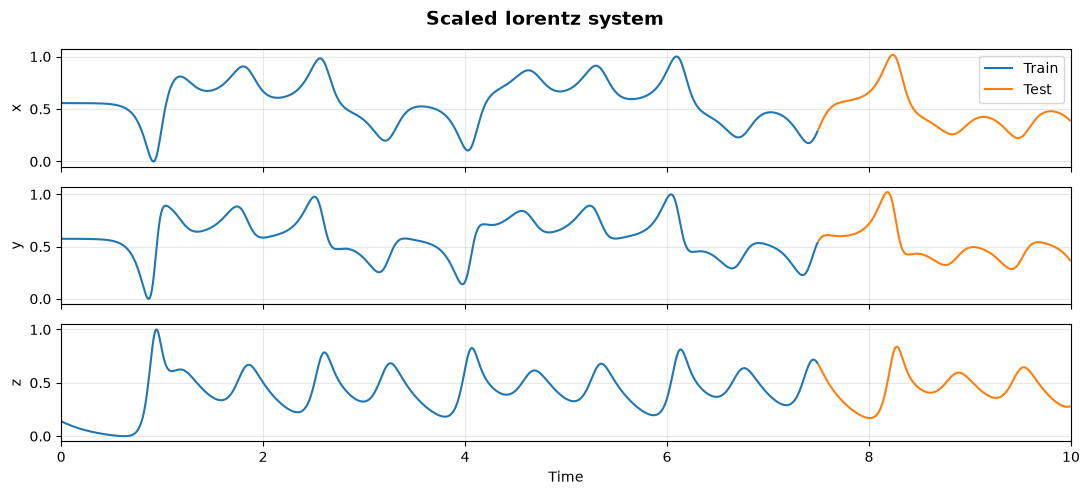

In [3]:
time = np.arange(npoints) * h
time_tr = time[:len(train_scaled)]
time_test = time[len(train_scaled):]

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)


axes[0].plot(time_tr, train_scaled[:, 0], label="Train")
axes[0].plot(time_test, test_scaled[:, 0], label="Test")
axes[0].legend()
axes[0].set_ylabel("x")
axes[0].grid(alpha=0.3)


axes[1].plot(time_tr, train_scaled[:, 1])
axes[1].plot(time_test, test_scaled[:, 1])
axes[1].set_ylabel("y")
axes[1].grid(alpha=0.3)

axes[2].plot(time_tr, train_scaled[:, 2])
axes[2].plot(time_test, test_scaled[:, 2])
axes[2].set_ylabel("z")
axes[2].set_xlabel("Time")
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0, 10)

fig.suptitle("Scaled lorentz system", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
def create_sequences(data, window_size, horizon):
    n_data = len(data)
    x = []
    y = []
    for i in range(window_size, n_data-horizon+1):
        x.append(data[i-window_size:i])
        y.append(data[i:i+horizon])
    return np.array(x), np.array(y)

# Independent-chanel VQC

In [ ]:
window_size = 5
horizon = 1
batch_size = 128

x_tr, hor_tr = create_sequences(train_scaled, window_size, horizon)
x_test, hor_test = create_sequences(test_scaled, window_size, horizon)

x_tr = torch.from_numpy(x_tr).double()
hor_tr = torch.from_numpy(hor_tr).double()

x_test = torch.from_numpy(x_test).double()
hor_test = torch.from_numpy(hor_test).double()

In [ ]:
def create_channel_loader(x, y, channel, batch_size=128, shuffle=False):
    """
    Creates a DataLoader for one independent time series channel.
    """
    # Select only one channel
    x_channel = x[:, :, channel] # (n_samples, window_size)
    y_channel = y[:, :, channel] # (n_samples, horizon)

    dataset = TensorDataset(x_channel, y_channel)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    return loader

In [ ]:
train_loader_x = create_channel_loader(x_tr, hor_tr, channel=0, batch_size=batch_size)
train_loader_y = create_channel_loader(x_tr, hor_tr, channel=1, batch_size=batch_size)
train_loader_z = create_channel_loader(x_tr, hor_tr, channel=2, batch_size=batch_size)

In [8]:
def angle_encoding(nqubits: int, inputs: list[float]) -> None:
    """
    Encodes classical input data into a quantum circuit using angle encoding 
    by applying Ry rotations with angle pi * input[i]
    """
    # Encode each classical value into one qubit
    for i in range(nqubits):
        qml.RY(np.pi * inputs[..., i], wires=i)

def QVC(nqubits: int, theta: list[float], reps: int) -> None:
    """
    Builds a variational quantum circuit.

    Each layer applies three parameterized rotations to every qubit:
    Rz -> Ry -> Rz.

    After the rotation block, a circular CNOT entangling layer is applied.
    """
    for rep in range(reps):
        # Rotation block
        for i in range(nqubits):
            base = rep * 3 * nqubits
            qml.RZ(theta[base + i], wires=i)
            qml.RY(theta[base + nqubits + i], wires=i)
            qml.RZ(theta[base + 2 * nqubits + i], wires=i)
        
        # Entangling block
        for i in range(nqubits-1):
            qml.CNOT(wires=[i, i+1])
        
        # Circular connection between last and first qubit
        qml.CNOT(wires=[nqubits-1, 0])

In [9]:
nqubits = window_size
nreps = 2
dev = qml.device("default.qubit", wires=nqubits)

def indep_chanel_vqc(inputs, theta):
    angle_encoding(nqubits, inputs)
    QVC(nqubits, theta, nreps)
    return qml.expval(qml.Z(0))

indep_chanel_vqc_node = qml.QNode(
    func=indep_chanel_vqc,
    device=dev,
    interface="torch",
    diff_method="adjoint"
)

In [ ]:
epochs = 50
lr = 5e-4

weights = {"theta": (3*nqubits*nreps,)}

# Convert the PennyLane QNode into a PyTorch layer
qlayer = qml.qnn.TorchLayer(indep_chanel_vqc_node, weights)

# Build the PyTorch model
model_x = torch.nn.Sequential(qlayer)
model_y = torch.nn.Sequential(qlayer)
model_z = torch.nn.Sequential(qlayer)

model_x.double()
model_y.double()
model_z.double()

opt_x = torch.optim.Adam(params=model_x.parameters(), lr=lr)
opt_y = torch.optim.Adam(params=model_y.parameters(), lr=lr)
opt_z = torch.optim.Adam(params=model_z.parameters(), lr=lr)

loss_fn = nn.MSELoss()

histories = []

loaders = (train_loader_x, train_loader_y, train_loader_z)
optimizers = (opt_x, opt_y, opt_z)
models = (model_x, model_y, model_z)

for loader, opt, model in zip(loaders, optimizers, models):
    print(30*"#")
    print("Starting training")
    print(30*"#")
    history = []
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad()
            pred = model(xb).squeeze()
            loss = loss_fn(pred, yb.squeeze())
            loss.backward()
            opt.step()
            history.append(loss.item())
        if epoch == 0 or epoch % 5 == 0:
            print(f"Epoch: {epoch+1} | Loss: {loss:.4f}")


##############################
Starting training
##############################
Epoch: 1 | Loss: 0.2281
Epoch: 2 | Loss: 0.2238
Epoch: 3 | Loss: 0.2197
Epoch: 4 | Loss: 0.2156
Epoch: 5 | Loss: 0.2116
Epoch: 6 | Loss: 0.2077
Epoch: 7 | Loss: 0.2039
Epoch: 8 | Loss: 0.2002
Epoch: 9 | Loss: 0.1966
Epoch: 10 | Loss: 0.1931
Epoch: 11 | Loss: 0.1897
Epoch: 12 | Loss: 0.1864
Epoch: 13 | Loss: 0.1831
Epoch: 14 | Loss: 0.1800
Epoch: 15 | Loss: 0.1769
Epoch: 16 | Loss: 0.1739
Epoch: 17 | Loss: 0.1710
Epoch: 18 | Loss: 0.1682
Epoch: 19 | Loss: 0.1654
Epoch: 20 | Loss: 0.1627
Epoch: 21 | Loss: 0.1601
Epoch: 22 | Loss: 0.1575
Epoch: 23 | Loss: 0.1550
Epoch: 24 | Loss: 0.1526
Epoch: 25 | Loss: 0.1502
Epoch: 26 | Loss: 0.1479
Epoch: 27 | Loss: 0.1457
Epoch: 28 | Loss: 0.1435
Epoch: 29 | Loss: 0.1413
Epoch: 30 | Loss: 0.1392
Epoch: 31 | Loss: 0.1372
Epoch: 32 | Loss: 0.1352
Epoch: 33 | Loss: 0.1332
Epoch: 34 | Loss: 0.1313
Epoch: 35 | Loss: 0.1294
Epoch: 36 | Loss: 0.1276
Epoch: 37 | Loss: 0.1258
Epoc

In [ ]:
def plot_loss(history, title = None) -> None:
    """
    Plots the training loss curve from the history of a model
    """
    epochs = np.array(range(len(history))) + 1
    plt.plot(epochs, history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    if title is not None:
        plt.title(title)
    plt.show()

display(plot_loss(histories[0], "Variable x"))
display(plot_loss(histories[1], "Variable y"))
display(plot_loss(histories[2], "Variable z"))

In [ ]:
# Select each channel independently

test_x = x_test[:, :, 0] # shape: (n_samples, window_size)
test_y = x_test[:, :, 1]
test_z = x_test[:, :, 2]

test_hor_x = hor_test[:, :, 0] # shape: (n_samples, horizon)
test_hor_y = hor_test[:, :, 1]
test_hor_z = hor_test[:, :, 2]

# Evaluation mode
model_x.eval()
model_y.eval()
model_z.eval()
with torch.no_grad():
    pred_x = model_x(test_x).reshape(-1, 1).numpy()
    pred_y = model_y(test_y).reshape(-1, 1).numpy()
    pred_z = model_z(test_z).reshape(-1, 1).numpy()

mse_x = (pred_x - test_hor_x)**2
mse_y = (pred_y - test_hor_y)**2
mse_z = (pred_z - test_hor_z)**2

mean_mse_x = mse_x.mean(dim=1)
mean_mse_y = mse_y.mean(dim=1)
mean_mse_z = mse_z.mean(dim=1)

errors = torch.cat([mean_mse_x, mean_mse_y, mean_mse_z], dim=1)  # (n_samples, 3)

mean_error_total = errors.mean(dim=1)  # (n_samples,)

In [ ]:
def plot_preds_and_error(pred_x, pred_y, pred_z, mean_error_total, title=None):

    fig, axes = plt.subplots(4, 1, figsize=(11, 5), sharex=True)

    # Time values aligned with predictions
    time_pred = time_test[window_size:window_size + len(pred_x)]

    # Real values aligned with predictions
    real_x = test_scaled[window_size:window_size + len(pred_x), 0]
    real_y = test_scaled[window_size:window_size + len(pred_y), 1]
    real_z = test_scaled[window_size:window_size + len(pred_z), 2]

    axes[0].plot(time_pred, real_x, label="Real values")
    axes[0].plot(time_pred, pred_x, label="Predicted values", linestyle="--")
    axes[0].legend()
    axes[0].set_ylabel("x")
    axes[0].grid(alpha=0.3)

    axes[1].plot(time_pred, real_y, label="Real values")
    axes[1].plot(time_pred, pred_y, label="Predicted values", linestyle="--")
    axes[1].set_ylabel("y")
    axes[1].grid(alpha=0.3)

    axes[2].plot(time_pred, real_z, label="Real values")
    axes[2].plot(time_pred, pred_z, label="Predicted values", linestyle="--")
    axes[2].set_ylabel("z")
    axes[2].grid(alpha=0.3)

    axes[3].plot(time_pred, mean_error_total, color="red", label="Mean error")
    axes[3].set_ylabel("Mean error")
    axes[3].set_xlabel("Time")
    axes[3].grid(alpha=0.3)

    axes[3].set_xlim(7.5, 10)

    if title is not None:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    
plot_preds_and_error(
    pred_x,
    pred_y,
    pred_z,
    mean_error_total,
    title="Independent channel VQC"
)